<a href="https://colab.research.google.com/github/gabopy-glitch/Aprendizaje-Estadistico-II/blob/main/ReturnRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score,

In [2]:
df = pd.read_csv("GSPC_data.csv")
df.head()

,date,GSPC.Open,GSPC.High,GSPC.Low,GSPC.Close,GSPC.Volume,GSPC.Adjusted
0,2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,9.318000e+08,1455.219971
1,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1.009000e+09,1399.420044
2,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1.085500e+09,1402.109985
3,2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1.092300e+09,1403.449951
4,2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1.225200e+09,1441.469971


In [3]:
df['GSPC.Return'] = df['GSPC.Close'].pct_change() * 100
display(df.head())

,date,GSPC.Open,GSPC.High,GSPC.Low,GSPC.Close,GSPC.Volume,GSPC.Adjusted,GSPC.Return
0,2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,9.318000e+08,1455.219971,NaN
1,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1.009000e+09,1399.420044,-3.834467
2,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1.085500e+09,1402.109985,0.192218
3,2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1.092300e+09,1403.449951,0.095568
4,2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1.225200e+09,1441.469971,2.709040


In [4]:
#Graficamos la distribución del rendimiento (gráfico de líneas)
plt.figure(figsize=(10, 6))


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

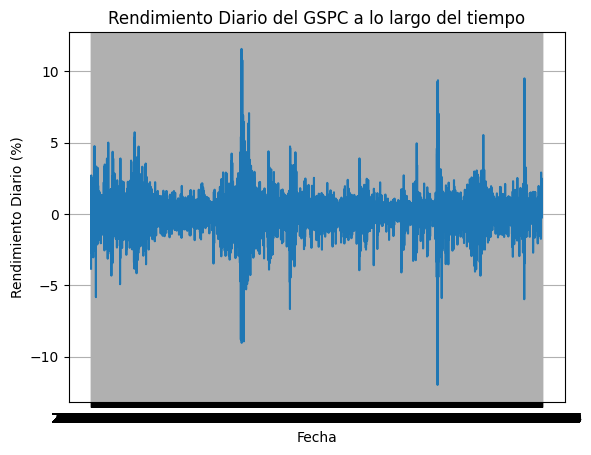

In [5]:
plt.plot(df['date'], df['GSPC.Return'])
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Diario (%)')
plt.title('Rendimiento Diario del GSPC a lo largo del tiempo')
plt.grid(True)
plt.show()

In [6]:
# Tomar la data desde 2015-01-01
df = df[df['date'] >= '2015-01-01']
df.head()

,date,GSPC.Open,GSPC.High,GSPC.Low,GSPC.Close,GSPC.Volume,GSPC.Adjusted,GSPC.Return
3773,2015-01-02,2058.899902,2072.360107,2046.040039,2058.199951,2.708700e+09,2058.199951,-0.033996
3774,2015-01-05,2054.439941,2054.439941,2017.339966,2020.579956,3.799120e+09,2020.579956,-1.827811
3775,2015-01-06,2022.150024,2030.250000,1992.439941,2002.609985,4.460110e+09,2002.609985,-0.889347
3776,2015-01-07,2005.550049,2029.609985,2005.550049,2025.900024,3.805480e+09,2025.900024,1.162984
3777,2015-01-08,2030.609985,2064.080078,2030.609985,2062.139893,3.934010e+09,2062.139893,1.788828


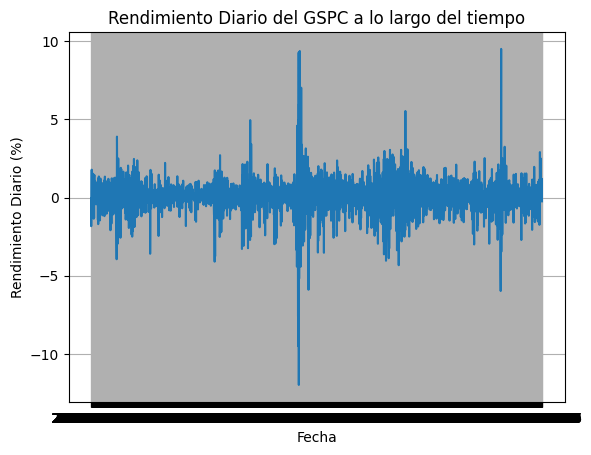

In [7]:
plt.plot(df['date'], df['GSPC.Return'])
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Diario (%)')
plt.title('Rendimiento Diario del GSPC a lo largo del tiempo')
plt.grid(True)
plt.show()

In [12]:
#Dividir la data entre entrenamiento y prueba
X = df[['GSPC.Open', 'GSPC.High', 'GSPC.Low', 'GSPC.Close', 'GSPC.Volume']]
y = df['GSPC.Return']

#Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Preparamos hiper parámetrso para el grid search
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#Instanciamos el Random Forest
rf_model = RandomForestRegressor(random_state=42)

#Grid Search
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
